### QQ Plot

---

#### Import library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

---

#### Import data

In [2]:
df = sns.load_dataset('iris')

<Axes: xlabel='sepal_length', ylabel='Density'>

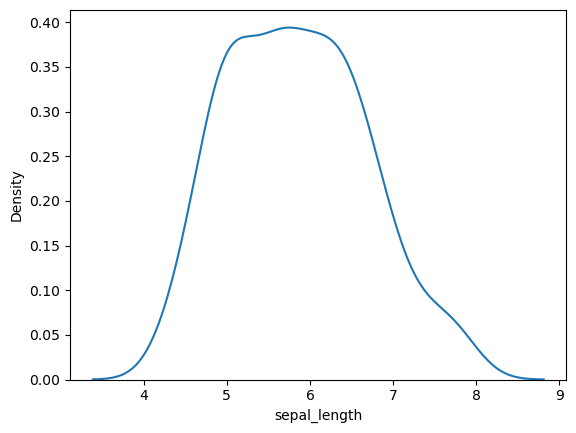

In [3]:
# Distribution plot
sns.kdeplot(df['sepal_length'])

#### QQ Plot

In [4]:
# Creating quantiles of normal data
temp = sorted(df['sepal_length'].tolist())

y_quant = []

for i in range(1,101):
  y_quant.append(np.percentile(temp,i))

In [5]:
# Creating quantiles of theoratical data
samples = np.random.normal(loc=0,scale=1,size=1000)

x_quant = []

for i in range(1,101):
  x_quant.append(np.percentile(samples,i))

<Axes: >

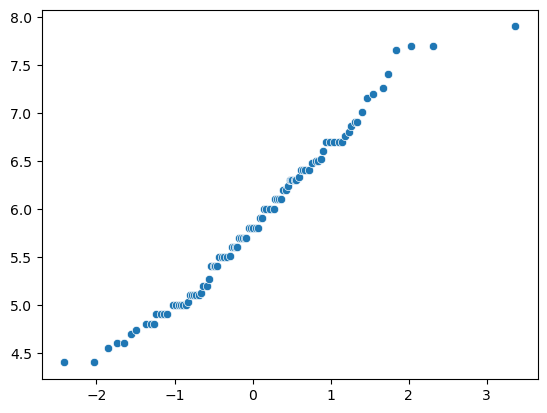

In [6]:
sns.scatterplot(x=x_quant,y=y_quant)

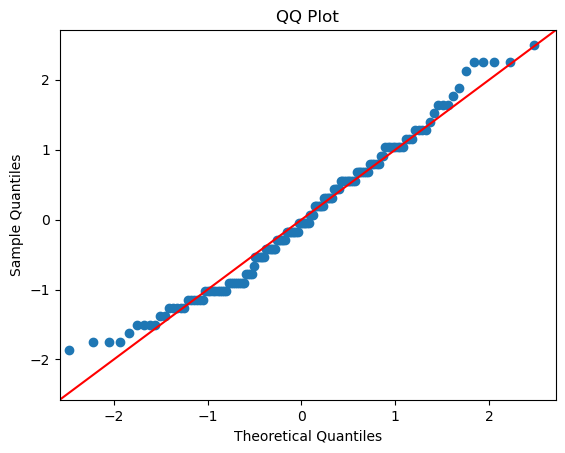

In [9]:
# using statsmodel

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create a QQ plot of the two sets of data
fig = sm.qqplot(df['sepal_length'], line='45', fit=True)

# Add a title and labels to the plot
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()


#### QQ plot not only test normality, but any kind of distribution

In [10]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate a set of random data
x = np.random.uniform(low=0, high=1, size=1000)

(array([121.,  99.,  99.,  83.,  96.,  89., 113., 104.,  95., 101.]),
 array([2.33055599e-04, 1.00164931e-01, 2.00096806e-01, 3.00028682e-01,
        3.99960557e-01, 4.99892432e-01, 5.99824308e-01, 6.99756183e-01,
        7.99688059e-01, 8.99619934e-01, 9.99551809e-01]),
 <BarContainer object of 10 artists>)

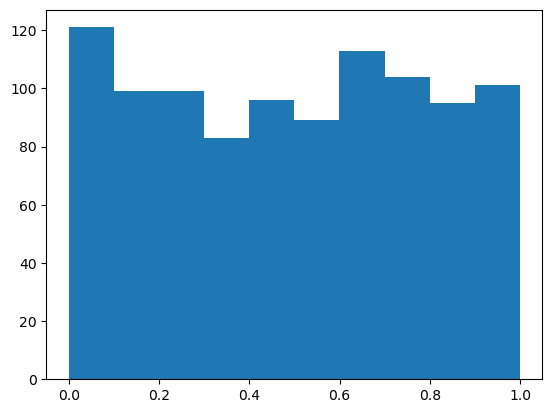

In [11]:
plt.hist(x)

In [12]:
# Fit a uniform distribution to the data
params = stats.uniform.fit(x)
dist = stats.uniform(loc=params[0], scale=params[1])

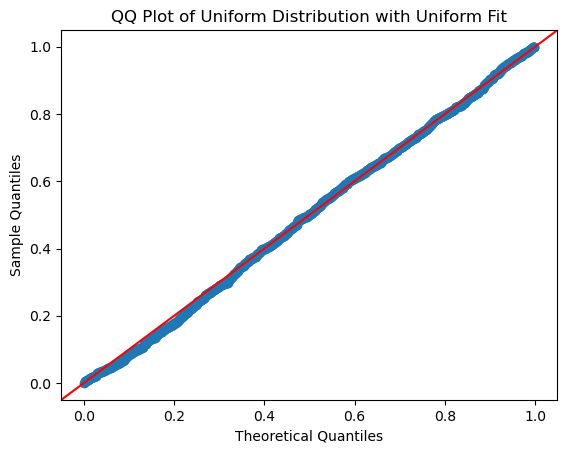

In [13]:
# Create a QQ plot of the data using the uniform distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title and labels to the plot
plt.title('QQ Plot of Uniform Distribution with Uniform Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()

---

### Pareto Distribution - log log plot

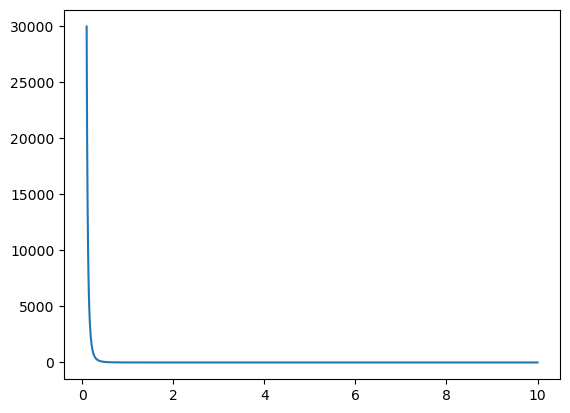

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 3
xm = 1

# Create an array of x values
x = np.linspace(0.1, 10, 1000)

# Calculate the y values of the Pareto distribution
y = alpha * (xm**alpha) / (x**(alpha+1))


plt.plot(x,y)

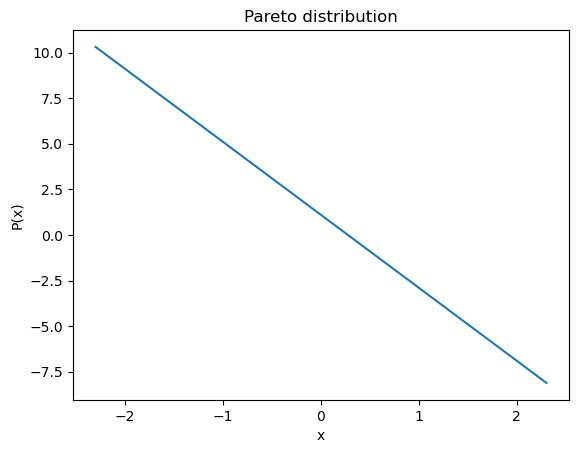

In [15]:
# Create the log-log plot
plt.plot(np.log(x),np.log(y))

# Add labels and a title
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Pareto distribution')

# Show the plot
plt.show()

#### Using QQ plot

In [16]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 2
xm = 1

# Generate a set of random data from the Pareto distribution
x = stats.pareto.rvs(b=alpha, scale=xm, size=1000)



(array([919.,  57.,  15.,   3.,   1.,   0.,   2.,   0.,   2.,   1.]),
 array([ 1.00108476,  3.46934332,  5.93760187,  8.40586043, 10.87411899,
        13.34237754, 15.8106361 , 18.27889465, 20.74715321, 23.21541177,
        25.68367032]),
 <BarContainer object of 10 artists>)

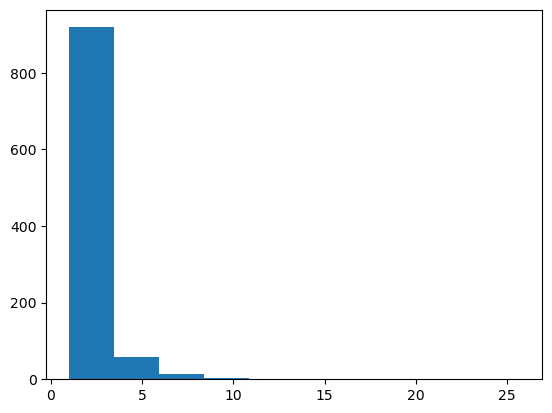

In [17]:
plt.hist(x)

In [18]:
# Fit a Pareto distribution to the data
params = stats.pareto.fit(x, floc=0)

# Create a Pareto distribution object with the fitted parameters
dist = stats.pareto(b=params[0], scale=params[2])


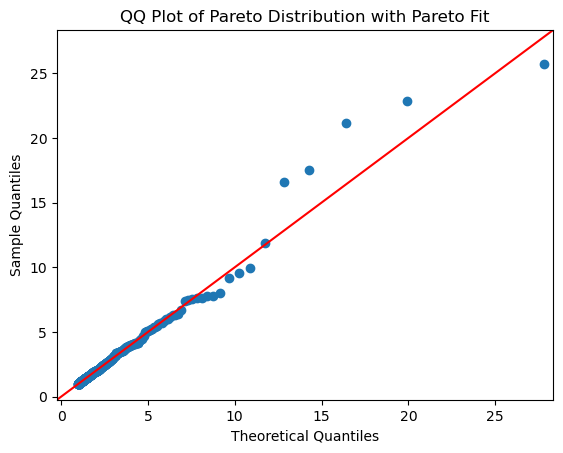

In [19]:
# Create a QQ plot of the data using the Pareto distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title and labels to the plot
plt.title('QQ Plot of Pareto Distribution with Pareto Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()